<a href="https://colab.research.google.com/github/ngocthi12123-cloud/Nh-n-d-ng-ti-n-gi-y-vi-t-nam-COLAB/blob/main/Untitled8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [39]:
import os
from google.colab import drive
drive.mount('/content/drive')

# =============================================================
# Đường dẫn dataset
# =============================================================
DATASET_PATH = "/content/drive/MyDrive/Ảnh Tiền"

CLASSES = ['10000', '20000', '50000', '100000', '200000', '500000']

IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32
EPOCHS = 50
NUM_CLASSES = len(CLASSES)

print(os.listdir(DATASET_PATH))
# Removed the line below as '/content/drive/MyDrive/Ảnh Tiền/train' was not found
# print(os.listdir(os.path.join(DATASET_PATH, "train")))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
['10000', '20000', '50000', '100000', '200000', '500000']


In [40]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

# 1. TIỀN XỬ LÝ DỮ LIỆU

# Thiết lập đường dẫn dữ liệu
train_dir = "/content/drive/MyDrive/Ảnh Tiền"

# Kích thước ảnh và kích thước lô
img_width, img_height = 224,224
batch_size = 32

# Tăng cường dữ liệu dành cho huấn luyện mô hình
train_datagen = ImageDataGenerator(
    rescale = 1.0/255,   # Normalize pixel values
    rotation_range = 30,
    width_shift_range = 0.2,
    height_shift_range = 0.2,
    shear_range = 0.2,
    zoom_range = 0.2,
    horizontal_flip = True,
    fill_mode = "nearest"
)

# Tải dữ liệu huấn luyện
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode="categorical"
)

# XÂY DỰNG MÔ HÌNH CNN
model = Sequential([
    Conv2D(32, (3,3), activation="relu", padding="same",
           input_shape=(img_width, img_height, 3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation="relu", padding="same"),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation="relu", padding="same"),
    MaxPooling2D(2,2),

    Conv2D(256, (3,3), activation="relu", padding="same"),
    MaxPooling2D(2,2),
    Conv2D(512, (3,3), activation="relu", padding="same"),
    MaxPooling2D(2,2),
    Conv2D(1024, (3,3), activation="relu", padding="same"),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(8192, activation="relu"),

    Dropout(0.5),  # Reduce overfitting

    Dense(6, activation="softmax")  # 5 categories
])

Found 60 images belonging to 6 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [41]:
# 4. Biên dịch mô hình
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [42]:
# 5. Huấn luyện mô hình
history = model.fit(train_generator, epochs=100)

Epoch 1/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 26s 12s/step - accuracy: 0.2000 - loss: 2.6790
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 547ms/step - accuracy: 0.2000 - loss: 1.8145
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 496ms/step - accuracy: 0.1833 - loss: 1.7823
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 492ms/step - accuracy: 0.2833 - loss: 1.7625
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 556ms/step - accuracy: 0.2833 - loss: 1.7323
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 889ms/step - accuracy: 0.2833 - loss: 1.7361
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 812ms/step - accuracy: 0.2833 - loss: 1.7304
Epoch 8/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 822ms/step - accuracy: 0.2833 - loss: 1.7323
Epoch 9/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 459ms/step - accuracy: 0.2833 - loss: 1.7133
Epoch 10/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 563ms/step - accuracy: 0.2833 - loss: 1.7119
Epoch 11/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 540ms/step - accuracy: 0.2833 - loss: 1.7399
Epoch 12/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 460ms/step - accuracy: 

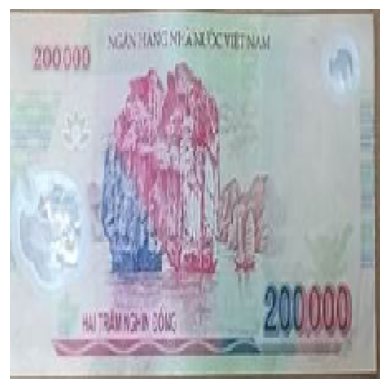

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
Người tiên đoán: 200000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Độ chính xác: 99.95%


In [46]:
from keras.utils import load_img, img_to_array
import numpy as np
import matplotlib.pyplot as plt
import os

# Lấy các nhãn lớp từ train_generator
class_labels = {v: k for k, v in train_generator.class_indices.items()}

# Đường dẫn đến ảnh để kiểm tra (chỉnh sửa nếu cần)
path = "/content/drive/MyDrive/Ảnh Tiền/200000/Screenshot 2026-05-30 103130.png"

if os.path.exists(path):
    # 1. Tải và hiển thị ảnh
    img = load_img(path, target_size=(img_width, img_height))
    plt.imshow(img)
    plt.axis('off')
    plt.show()

    # 2. Chuyển đổi sang mảng và chuẩn hóa
    img_array = img_to_array(img)
    img_array = img_array / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    # 3. Tiên đoán
    prediction = np.argmax(model.predict(img_array))

    # 4. Ánh xạ nhãn tên người
    predicted_class_name = class_labels.get(prediction, "Không xác định")

    print(f"Người tiên đoán: {predicted_class_name}")
    print(f"Độ chính xác: {np.max(model.predict(img_array)) * 100:.2f}%")
else:
    print(f"Lỗi: Không tìm thấy ảnh tại {path}. Vui lòng kiểm tra lại đường dẫn.")